In [1]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageColor
from sklearn.mixture import GaussianMixture
from matplotlib.colors import ListedColormap
from sklearn.manifold import TSNE

mpl.rcParams['font.family'] = 'Noto Sans'
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'

In [ ]:
seed = 44
data_path = 'path_to_tetrominoes_data'
gmm_logs = 'path_to_GMM_logs/'
vae_logs = 'path_to_vae_logs/'
ldm_logs = 'path_to_ldm_logs/'
slot_attn_logs = 'path_to_slot_attention_logs/'
slot_vae_logs = 'path_to_slot_vae_logs/'
mixture_mpm_logs = 'path_to_mixture_decoder_logs/'
additive_mpm_logs = 'path_to_additive_decoder_logs/'

In [3]:
H, W = 35, 35
mask_colors_names = ['red', 'limegreen', 'dodgerblue', 'darkviolet']
mask_colors = [ImageColor.getrgb(c) for c in mask_colors_names]

def load_prediction_arrays(log_dir):
    possible_dirs = [
        log_dir,
        os.path.join(log_dir, "predictions"),
        os.path.join(log_dir, "predictions", "vae"),
        os.path.join(log_dir, "predictions", "diffusion"),
    ]
    
    filenames = ["images.npy", "objects.npy", "alphas.npy"]
    for base_dir in possible_dirs:
        paths = {name: os.path.join(base_dir, name) for name in filenames}
        if all(os.path.isfile(path) for path in paths.values()):
            return (
                np.load(paths["images.npy"]),
                np.load(paths["objects.npy"]),
                np.load(paths["alphas.npy"]),
            )
    raise FileNotFoundError(
        "Could not find images.npy, objects.npy, and alphas.npy "
        "in any of the expected locations:\n" + "\n".join(possible_dirs)
    )

def load_data(log_dir):
    imgs, objects, alphas = load_prediction_arrays(log_dir)
    if alphas.ndim == 4:
        alphas = alphas[:, :, :, :, None]
    if imgs.shape[1] == 3:
        imgs = np.transpose(imgs, (0,2,3,1))
    if objects.shape[1] == 3:
        objects = np.transpose(objects, (0,2,3,1))
    objects = np.clip(objects, a_min=0, a_max=1)
    objects = objects.reshape((-1, 4, 35, 35, 3))
    mask_idx = np.argmax(alphas, axis=1)
    recons = np.sum(objects, axis=1)
    imgs = (imgs * 255).round().astype(np.uint8)
    objects = (objects * 255).round().astype(np.uint8)
    recons = (recons * 255).round().astype(np.uint8)
    return imgs, objects, mask_idx, recons

def plot_img(ax, img, title='', border_color=None, border_thickness=1):
    if border_color is not None:
        img = Image.fromarray(img, mode='RGB')
        img = ImageOps.expand(
            img, fill=border_color,
            border=border_thickness,
        )
        img = np.array(img)
    ax.imshow(img)
    ax.tick_params(
        axis='both', which='both',
        bottom=False, top=False, left=False, right=False,
        labelbottom=False, labelleft=False
    )
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, fontsize=18)

def plot_model(ax, log_dir, model, idx, include_titles=True):
    imgs, objects, mask_idx, recons = load_data(log_dir)
    # Original image
    title = 'Image' if include_titles else ''
    plot_img(ax[0], imgs[idx], title, border_color='black')
    ax[0].set_ylabel(model, fontsize=18)
    # Reconstruction
    title = 'Recon.' if include_titles else ''
    plot_img(ax[1], recons[idx], title, border_color='black')
    # Alpha mask
    title = 'Mask' if include_titles else ''
    seg_mask = np.zeros((H, W, 3), dtype=np.uint8)
    for i in range(H):
        for j in range(W):
            seg_mask[i][j] = mask_colors[mask_idx[idx][i][j][0]]
    plot_img(ax[2], seg_mask, title, border_color='black')
    # Objects
    for i in range(4):
        title = f'Object {i+1}' if include_titles else ''
        plot_img(
            ax[i+3], objects[idx][i], title, 
            border_color=mask_colors[i],
        )

def num_objects(log_dir, idx):
    _, objects, _, _ = load_data(log_dir)
    # Objects
    n = 0
    for i in range(4):
        if objects[idx][i].sum() > 2000:
            n += 1
    return n

In [4]:
imgs = np.load(f'{gmm_logs}/seed={seed}/images.npy')
objects = []
alphas = []
recons = []
mask_idx = []
gmm = GaussianMixture(
    max_iter=100,
    n_components=4,
    covariance_type="full",
    init_params="kmeans",
    random_state=42,
)
for img in imgs:
    data = img.reshape(-1, 3)
    gmm.fit(data)

    probs = gmm.predict_proba(data).T
    masks = probs.reshape((4, 35, 35, 1))
    centers = gmm.means_[:, None, None, :]
    centers = np.broadcast_to(centers, (4, 35, 35, 3))
    masked_centers = masks * centers

    alphas.append(masks[None,])
    objects.append(masked_centers[None,])
    recons.append(np.sum(masked_centers, axis=0)[None,])
    mask_idx.append(np.argmax(masks, axis=0)[None,])

objects = np.vstack(objects)
alphas = np.vstack(alphas)
mask_idx = np.vstack(mask_idx)
recons = np.vstack(recons)
np.save(f'{gmm_logs}/seed={seed}/objects.npy', objects)
np.save(f'{gmm_logs}/seed={seed}/alphas.npy', alphas)

imgs = (imgs * 255).round().astype(np.uint8)
objects = (objects * 255).round().astype(np.uint8)
recons = (recons * 255).round().astype(np.uint8)

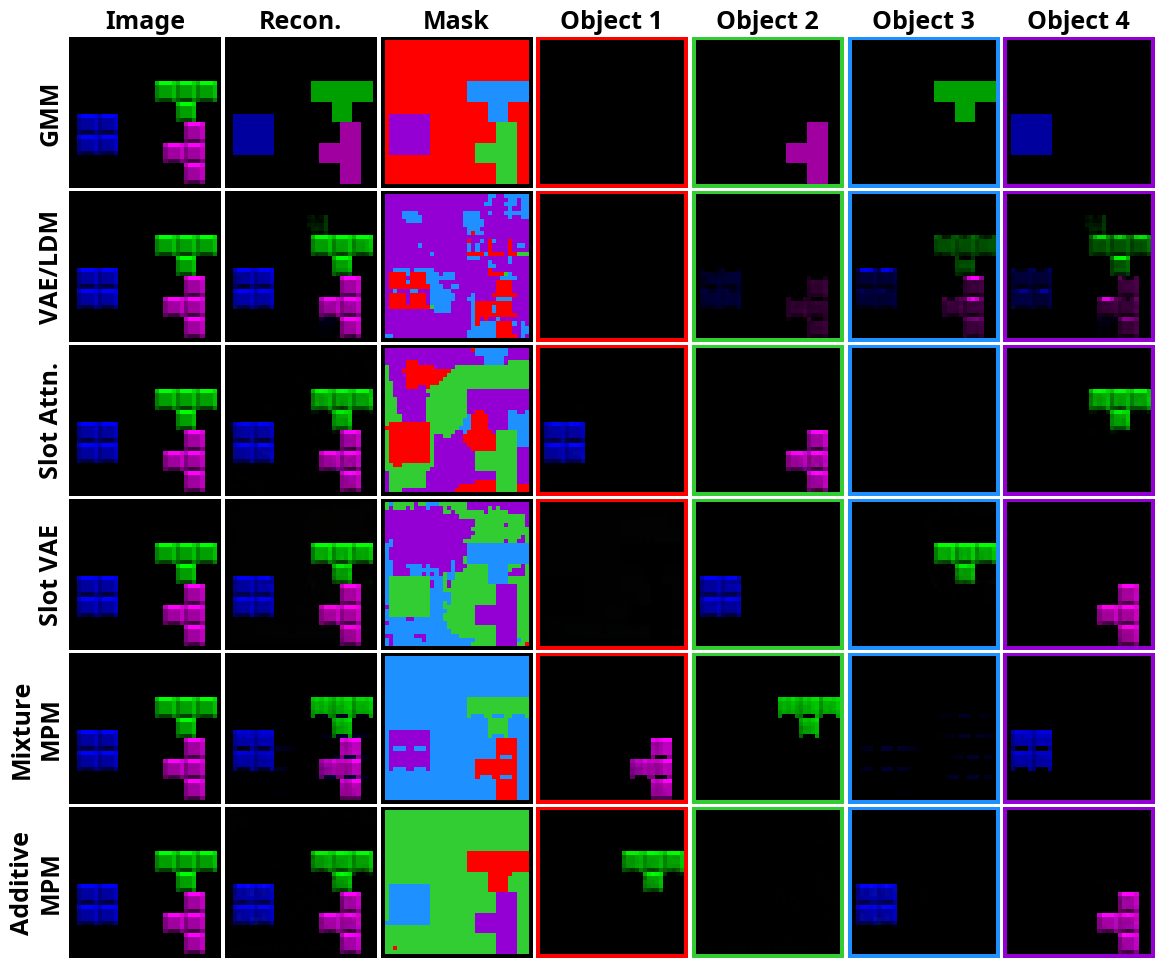

In [ ]:
log_dirs = [
    f'{ldm_logs}/seed={seed}',
    f'{slot_attn_logs}/seed={seed}',
    f'{slot_vae_logs}/tetrominoes-seed={seed}',
    f'{mixture_mpm_logs}/beta=0.01-seed={seed}',
    f'{additive_mpm_logs}/beta=0.0-seed={seed}',
]
models = [
    'VAE/LDM',
    'Slot Attn.',
    'Slot VAE',
    'Mixture\nMPM',
    'Additive\nMPM',    
]
M = len(models)

idx = 9
fig, ax = plt.subplots(M+1, 7, figsize=(14,12))
plot_img(ax[0][0], imgs[idx], border_color='black', title='Image')
plot_img(ax[0][1], recons[idx], border_color='black', title='Recon.')
seg_mask = np.zeros((H, W, 3), dtype=np.uint8)
for i in range(H):
    for j in range(W):
        seg_mask[i][j] = mask_colors[mask_idx[idx][i][j][0]]
plot_img(ax[0][2], seg_mask, border_color='black', title='Mask')
for i in range(4):
    plot_img(ax[0][i+3], objects[idx][i], border_color=mask_colors[i], title=f'Object {i+1}') 
ax[0][0].set_ylabel('GMM', fontsize=18)

for i in range(M):
    plot_model(ax[i+1], log_dirs[i], models[i], idx, include_titles=False)

plt.subplots_adjust(wspace=0.03, hspace=0.0)
plt.savefig(f'comparison.jpg', dpi=600, bbox_inches='tight')

In [6]:
r = np.load(f'{additive_mpm_logs}/beta=0.0-seed={seed}/predictions/mixing.npy')
slots = np.load(f'{additive_mpm_logs}/beta=0.0-seed={seed}/predictions/slots.npy')
objects = np.load(f'{additive_mpm_logs}/beta=0.0-seed={seed}/predictions/objects.npy')
objects = np.clip(objects, a_min=0, a_max=1)
objects = (objects * 255).round().astype(np.uint8)

cluster_idx = np.argmax(r, axis=1)
cluster_sizes = {i:0 for i in range(100)}
for k in cluster_idx:
    cluster_sizes[k] += 1
arr = [(v,k) for k,v in cluster_sizes.items()]
arr.sort(reverse=True)

cluster_reps = {i:[] for i in range(100)}
for idx,k in enumerate(cluster_idx):
    score = float(r[idx][k])
    cluster_reps[k].append((score, idx))
for i in range(100):
    cluster_reps[i].sort(reverse=True)
for i in range(100):
    arr = cluster_reps[i]
    cluster_reps[i] = [tup[1] for tup in arr]

colors = []
viz_slots = []
viz_clusters = [24, 33, 27, 77]
for c in viz_clusters:
    count = 0
    for i,s in enumerate(slots):
        if cluster_idx[i] == c:
            viz_slots.append(s)
            colors.append(cluster_idx[i])
            count += 1
        if count == 100:
            break
viz_slots = np.vstack(viz_slots)
tsne = TSNE(n_components=2, random_state=42)
tsne_slots = tsne.fit_transform(
    (viz_slots - np.mean(viz_slots, axis=1, keepdims=True)) / np.std(viz_slots, axis=1, keepdims=True)
)

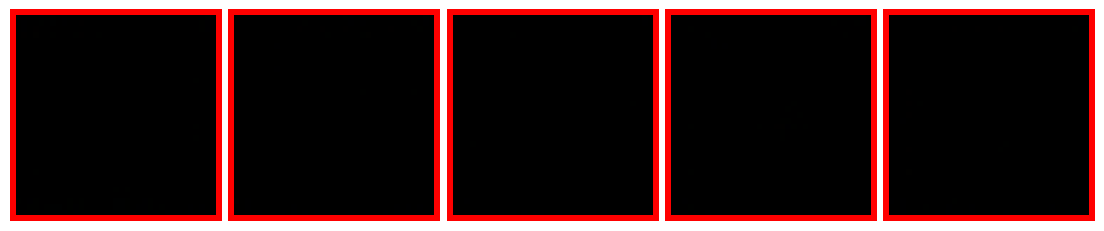

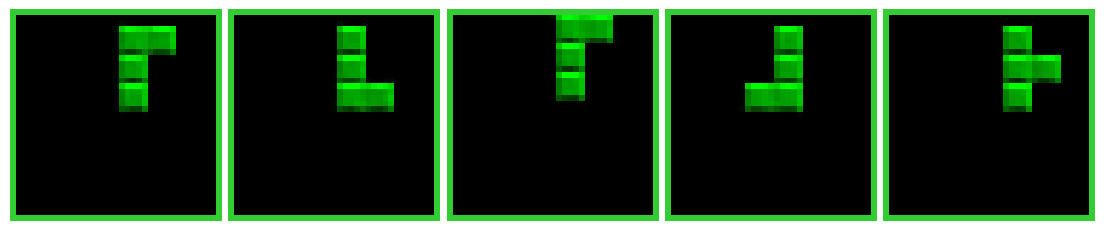

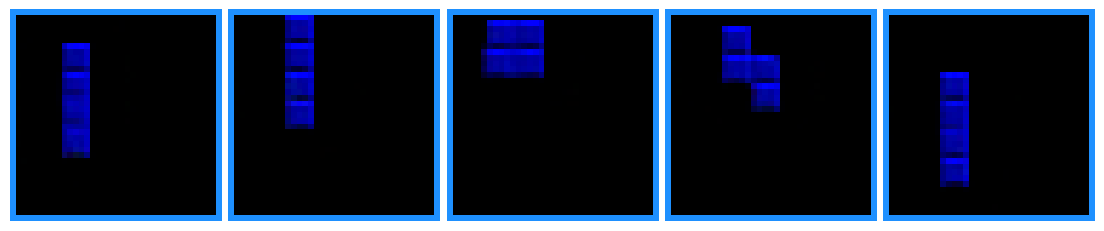

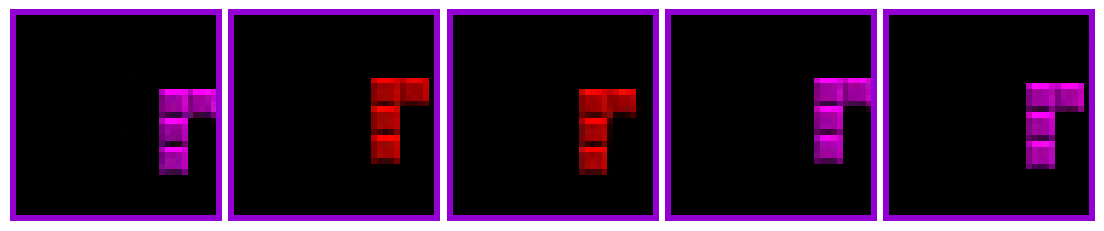

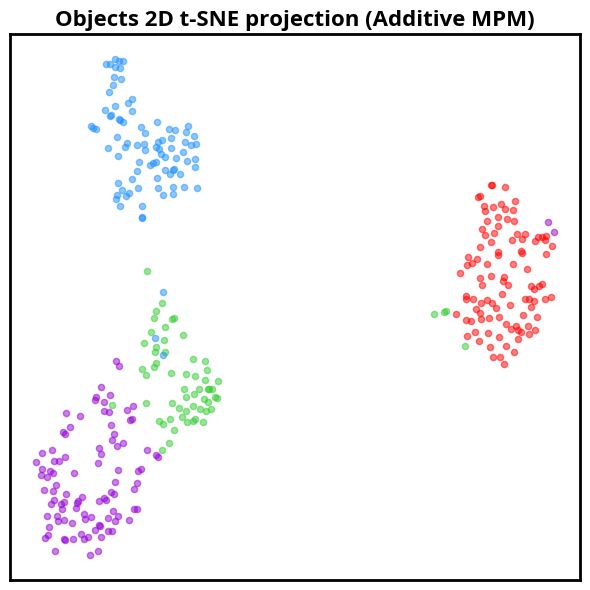

In [7]:
for i in range(4):
    fig, ax = plt.subplots(1, 5, figsize=(14,6))
    for j in range(5):
        idx = cluster_reps[viz_clusters[i]][j]
        plot_img(ax[j], objects[idx], border_color=mask_colors[i])
    plt.subplots_adjust(wspace=0.03, hspace=0.0)
    plt.savefig(
        f'additive-mpm-{mask_colors_names[i]}-cluster.png', 
        dpi=600, bbox_inches='tight', transparent=True
    )

label_to_color = {label: idx for idx, label in enumerate(viz_clusters)}
color_indices = np.array([label_to_color[c] for c in colors])
cmap = ListedColormap(mask_colors_names)

fig, ax = plt.subplots(figsize=(6, 6))
for i in range(4):
    idxs = [idx for idx,c in enumerate(color_indices) if c == i]
    ax.scatter(
        tsne_slots[idxs, 0], 
        tsne_slots[idxs, 1],
        c=mask_colors_names[i], 
        s=20, alpha=0.5,
        label=f'{viz_clusters[i]}',
    )
ax.set_title("Objects 2D t-SNE projection (Additive MPM)", fontsize=16)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig(
    f'additive-mpm-scatter.jpg', 
    dpi=600, bbox_inches='tight'
)

In [8]:
r = np.load(f'{mixture_mpm_logs}/beta=0.01-seed={seed}/predictions/mixing.npy')
slots = np.load(f'{mixture_mpm_logs}/beta=0.01-seed={seed}/predictions/slots.npy')
objects = np.load(f'{mixture_mpm_logs}/beta=0.01-seed={seed}/predictions/objects.npy')
objects = np.clip(objects, a_min=0, a_max=1)
objects = (objects * 255).round().astype(np.uint8)

cluster_idx = np.argmax(r, axis=1)
cluster_sizes = {i:0 for i in range(100)}
for k in cluster_idx:
    cluster_sizes[k] += 1
arr = [(v,k) for k,v in cluster_sizes.items()]
arr.sort(reverse=True)

cluster_reps = {i:[] for i in range(100)}
for idx,k in enumerate(cluster_idx):
    score = float(r[idx][k])
    cluster_reps[k].append((score, idx))
for i in range(100):
    cluster_reps[i].sort(reverse=True)
for i in range(100):
    arr = cluster_reps[i]
    cluster_reps[i] = [tup[1] for tup in arr]

colors = []
viz_slots = []
viz_clusters = [48, 15, 36, 21]
for c in viz_clusters:
    count = 0
    for i,s in enumerate(slots):
        if cluster_idx[i] == c:
            viz_slots.append(s)
            colors.append(cluster_idx[i])
            count += 1
        if count == 100:
            break
viz_slots = np.vstack(viz_slots)
tsne = TSNE(n_components=2, random_state=42)
tsne_slots = tsne.fit_transform(
    (viz_slots - np.mean(viz_slots, axis=1, keepdims=True)) / np.std(viz_slots, axis=1, keepdims=True)
)

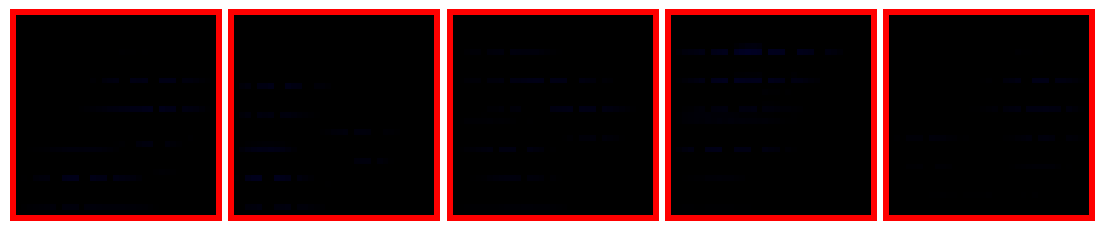

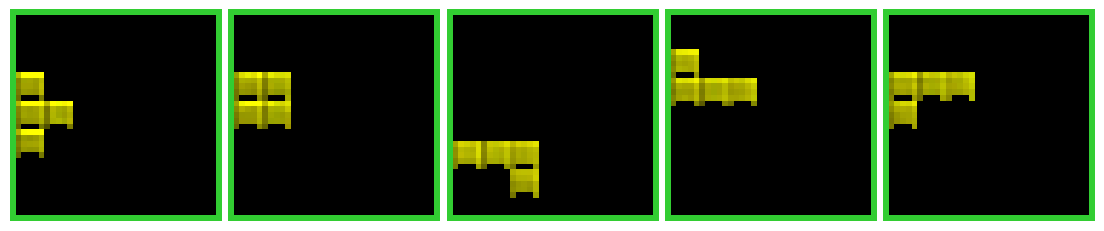

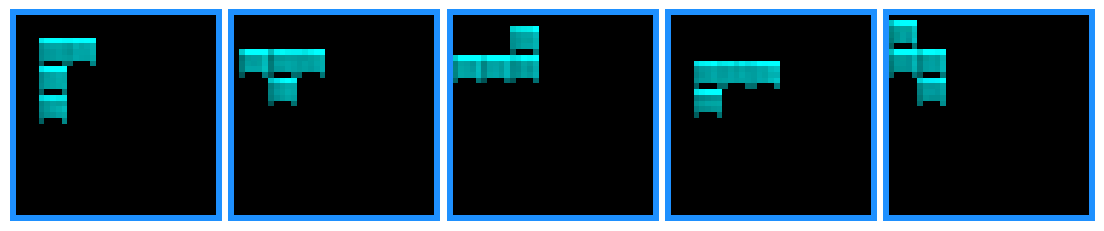

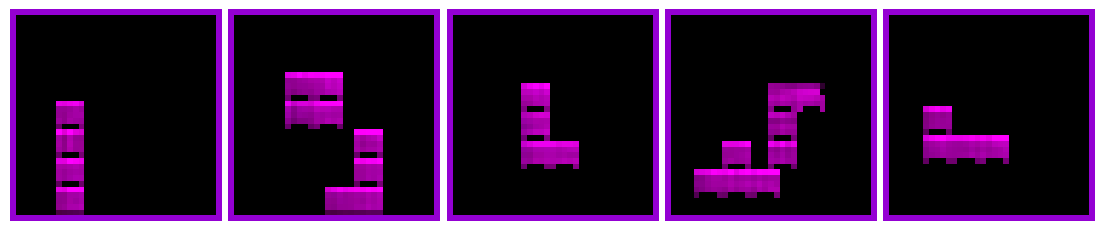

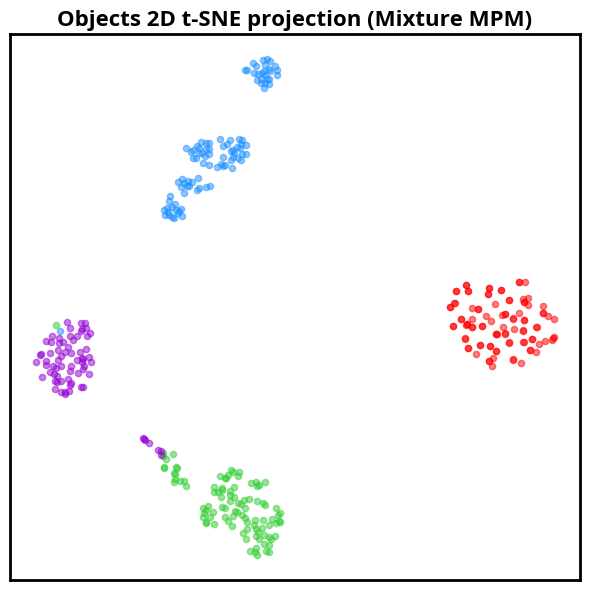

In [9]:
for i in range(4):
    fig, ax = plt.subplots(1, 5, figsize=(14,6))
    for j in range(5):
        idx = cluster_reps[viz_clusters[i]][j]
        plot_img(ax[j], objects[idx], border_color=mask_colors[i])
    plt.subplots_adjust(wspace=0.03, hspace=0.0)
    plt.savefig(
        f'mixture-mpm-{mask_colors_names[i]}-cluster.png', 
        dpi=600, bbox_inches='tight', transparent=True
    )

label_to_color = {label: idx for idx, label in enumerate(viz_clusters)}
color_indices = np.array([label_to_color[c] for c in colors])
cmap = ListedColormap(mask_colors_names)

fig, ax = plt.subplots(figsize=(6, 6))
for i in range(4):
    idxs = [idx for idx,c in enumerate(color_indices) if c == i]
    ax.scatter(
        tsne_slots[idxs, 0], 
        tsne_slots[idxs, 1],
        c=mask_colors_names[i], 
        s=20, alpha=0.5,
        label=f'{viz_clusters[i]}',
    )
ax.set_title("Objects 2D t-SNE projection (Mixture MPM)", fontsize=16)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig(
    f'mixture-mpm-scatter.jpg', 
    dpi=600, bbox_inches='tight'
)